### Task 2
##### Layyana Junaid 23k0056

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [7]:
data = 'data/master_metadata.csv'  

meta = pd.read_csv(data)
print(meta.shape)
meta.head(10)

(300, 6)


,Patient_ID,Age,Gender,Modality,Num_Slices,Folder_Path
0,Patient_001,74,F,CT,66,synthetic_slices/Patient_001/CT/
1,Patient_001,74,F,MRI,84,synthetic_slices/Patient_001/MRI/
2,Patient_002,40,M,CT,110,synthetic_slices/Patient_002/CT/
3,Patient_002,40,M,MRI,79,synthetic_slices/Patient_002/MRI/
4,Patient_003,80,M,CT,77,synthetic_slices/Patient_003/CT/
5,Patient_003,80,M,MRI,77,synthetic_slices/Patient_003/MRI/
6,Patient_004,41,F,CT,92,synthetic_slices/Patient_004/CT/
7,Patient_004,41,F,MRI,72,synthetic_slices/Patient_004/MRI/
8,Patient_005,46,M,CT,117,synthetic_slices/Patient_005/CT/
9,Patient_005,46,M,MRI,57,synthetic_slices/Patient_005/MRI/


In [9]:
import os

for item in os.listdir('data'):
    print(item)

print('---')
# Check one level into whichever synthetic_slices folder actually exists
for item in os.listdir('data/synthetic_slices (2)'):
    print(item)

archive (1)
master_metadata.csv
synthetic_slices (2)
---
synthetic_slices


CT slices: 66, sample: ['slice_001.png', 'slice_002.png', 'slice_003.png']
MRI slices: 84, sample: ['slice_001.png', 'slice_002.png', 'slice_003.png']


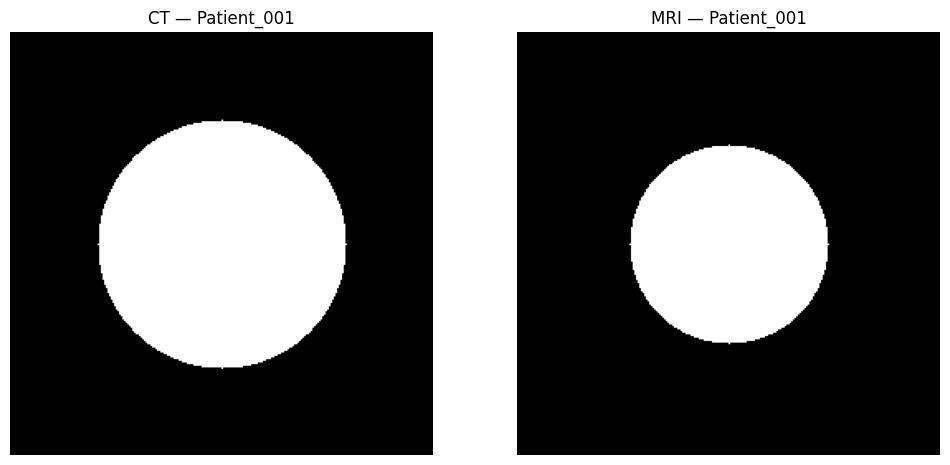

In [ ]:
patient_id = 'Patient_001'

base = 'data/synthetic_slices (2)'  

ct_folder = f'{base}/synthetic_slices/{patient_id}/CT/'
mri_folder = f'{base}/synthetic_slices/{patient_id}/MRI/'

ct_files = sorted(os.listdir(ct_folder))
mri_files = sorted(os.listdir(mri_folder))

print(f"CT slices: {len(ct_files)}, sample: {ct_files[:3]}")
print(f"MRI slices: {len(mri_files)}, sample: {mri_files[:3]}")

ct_path = os.path.join(ct_folder, ct_files[len(ct_files) // 2])
mri_path = os.path.join(mri_folder, mri_files[len(mri_files) // 2])

ct_img = cv2.imread(ct_path, cv2.IMREAD_GRAYSCALE)
mri_img = cv2.imread(mri_path, cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(ct_img, cmap='gray')
axes[0].set_title(f'CT — {patient_id}')
axes[0].axis('off')

axes[1].imshow(mri_img, cmap='gray')
axes[1].set_title(f'MRI — {patient_id}')
axes[1].axis('off')
plt.show()

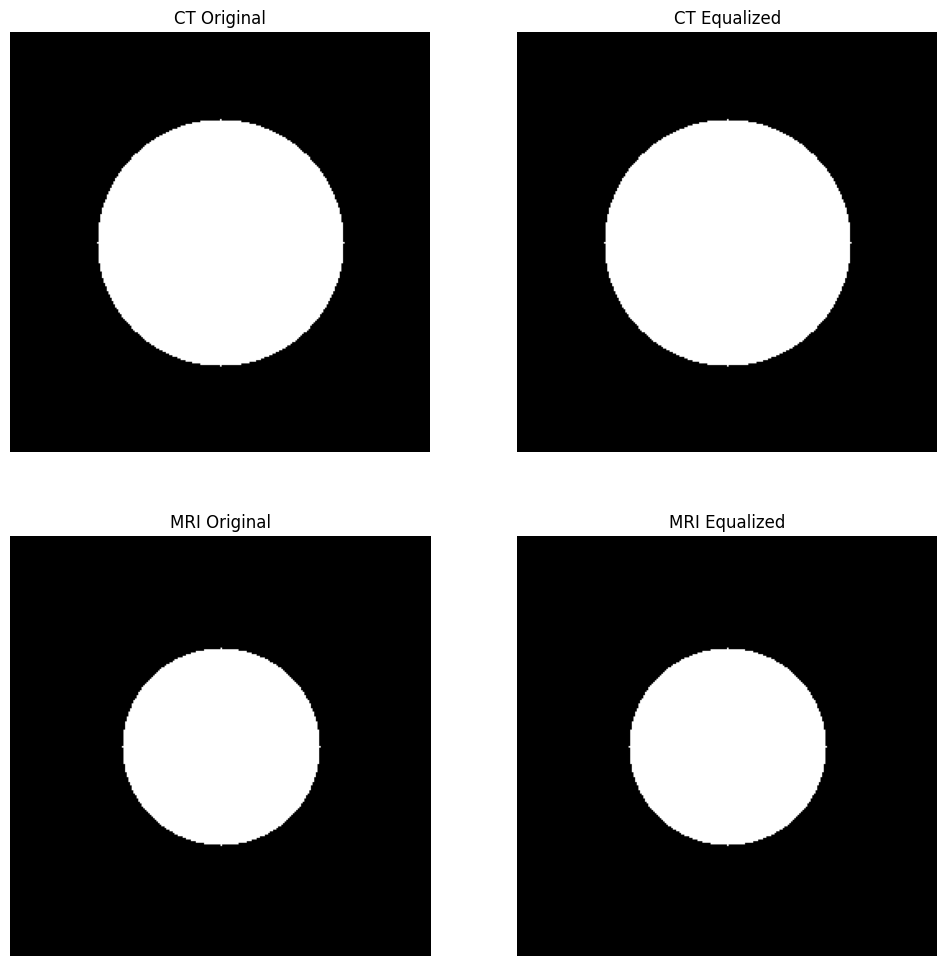

In [11]:
ct_eq = cv2.equalizeHist(ct_img)
mri_eq = cv2.equalizeHist(mri_img)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0,0].imshow(ct_img, cmap='gray'); axes[0,0].set_title('CT Original'); axes[0,0].axis('off')
axes[0,1].imshow(ct_eq, cmap='gray'); axes[0,1].set_title('CT Equalized'); axes[0,1].axis('off')
axes[1,0].imshow(mri_img, cmap='gray'); axes[1,0].set_title('MRI Original'); axes[1,0].axis('off')
axes[1,1].imshow(mri_eq, cmap='gray'); axes[1,1].set_title('MRI Equalized'); axes[1,1].axis('off')
plt.show()

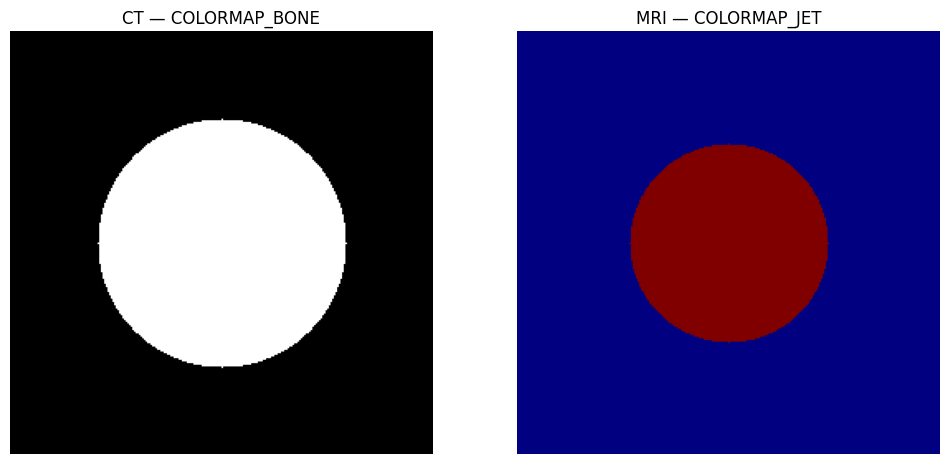

In [12]:
ct_colored = cv2.applyColorMap(ct_eq, cv2.COLORMAP_BONE)
mri_colored = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)

ct_colored_rgb = cv2.cvtColor(ct_colored, cv2.COLOR_BGR2RGB)
mri_colored_rgb = cv2.cvtColor(mri_colored, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(ct_colored_rgb)
axes[0].set_title('CT — COLORMAP_BONE')
axes[0].axis('off')

axes[1].imshow(mri_colored_rgb)
axes[1].set_title('MRI — COLORMAP_JET')
axes[1].axis('off')
plt.show()

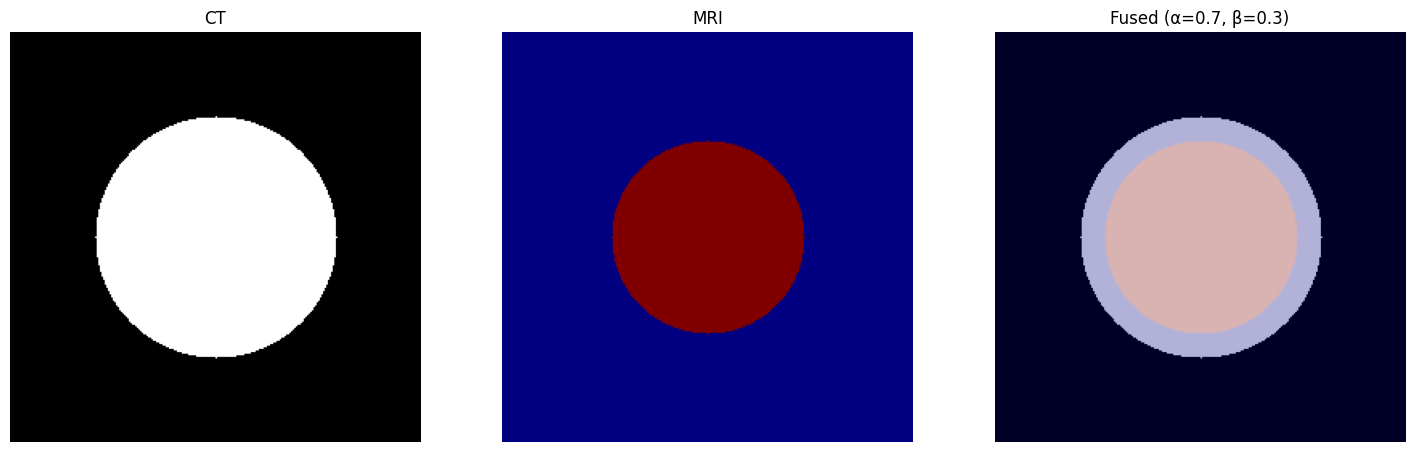

In [13]:
alpha = 0.7  
beta = 0.3   
gamma_offset = 0  

fused = cv2.addWeighted(ct_colored, alpha, mri_colored, beta, gamma_offset)
fused_rgb = cv2.cvtColor(fused, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(ct_colored_rgb)
axes[0].set_title('CT')
axes[0].axis('off')

axes[1].imshow(mri_colored_rgb)
axes[1].set_title('MRI')
axes[1].axis('off')

axes[2].imshow(fused_rgb)
axes[2].set_title(f'Fused (α={alpha}, β={beta})')
axes[2].axis('off')
plt.show()

Fused min: 0, max: 217, mean: 60.74


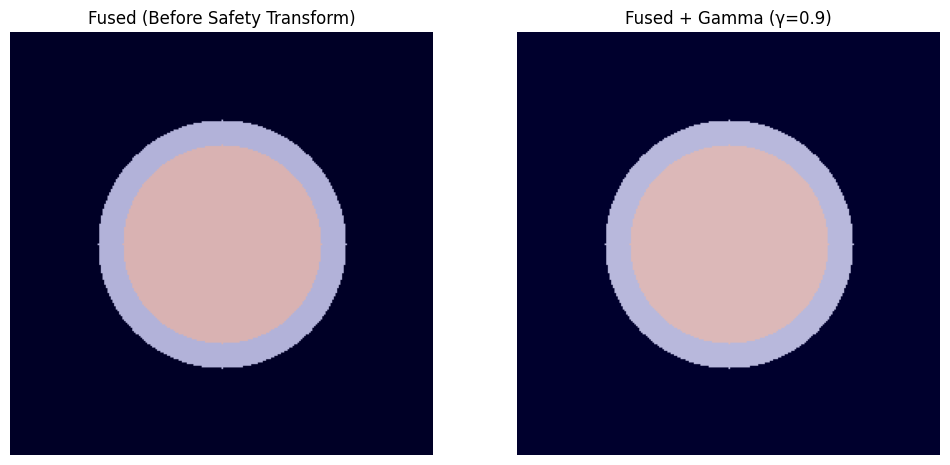

In [14]:
print(f"Fused min: {fused.min()}, max: {fused.max()}, mean: {fused.mean():.2f}")

gamma = 0.9
fused_norm = fused.astype(np.float32) / 255.0
fused_gamma = np.power(fused_norm, gamma)
fused_gamma = (fused_gamma * 255).clip(0, 255).astype(np.uint8)
fused_gamma_rgb = cv2.cvtColor(fused_gamma, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(fused_rgb)
axes[0].set_title('Fused (Before Safety Transform)')
axes[0].axis('off')

axes[1].imshow(fused_gamma_rgb)
axes[1].set_title(f'Fused + Gamma (γ={gamma})')
axes[1].axis('off')
plt.show()

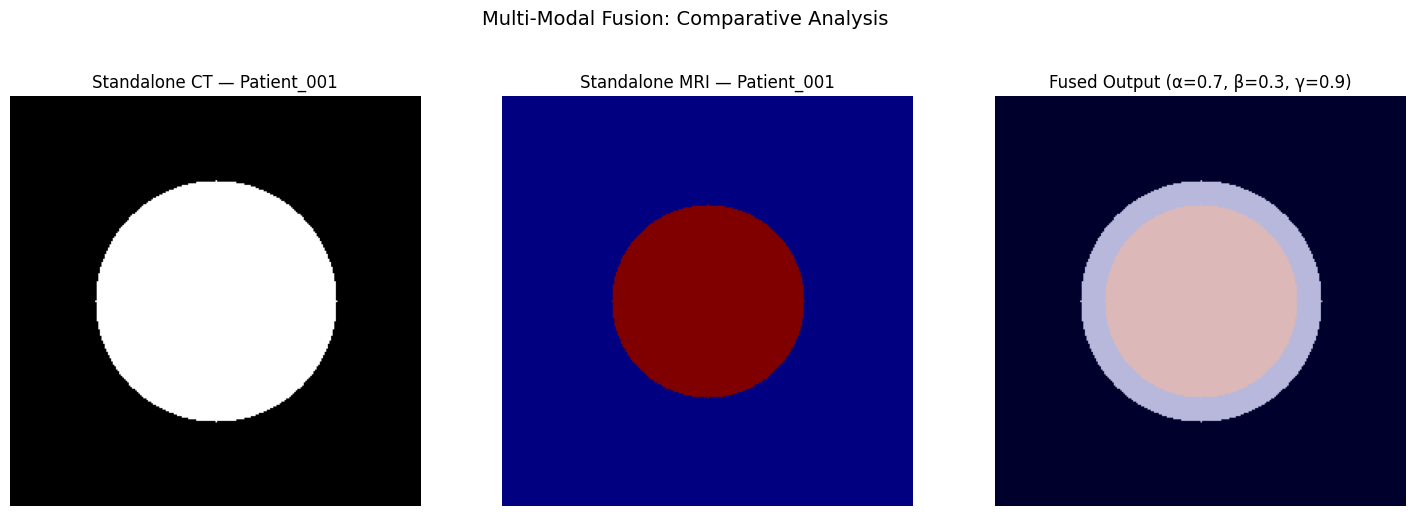

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(ct_colored_rgb)
axes[0].set_title(f'Standalone CT — {patient_id}')
axes[0].axis('off')

axes[1].imshow(mri_colored_rgb)
axes[1].set_title(f'Standalone MRI — {patient_id}')
axes[1].axis('off')

axes[2].imshow(fused_gamma_rgb)
axes[2].set_title(f'Fused Output (α={alpha}, β={beta}, γ={gamma})')
axes[2].axis('off')
plt.suptitle('Multi-Modal Fusion: Comparative Analysis', fontsize=14)
plt.show()